<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch03_Heterogeneous_Ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Heterogeneous Parallel Ensembles: Combining Strong Learners

*Companion notebook to Chapter 3 of* **Ensemble Methods for Machine Learning** *by Gautam Kunapuli (Manning, 2023). Notebook adapted, executed, and annotated for instructional use.*

In Chapter 2 we built **homogeneous ensembles** — bagging and random forests — where every base estimator came from the same learning algorithm and diversity arose only from random sampling. This chapter takes the opposite path: **heterogeneous ensembles** that achieve diversity *directly* by training base estimators with **different learning algorithms**. We will combine, for example, a decision tree, an SVM, a Gaussian process, a $k$-NN, a random forest, and a Gaussian naïve Bayes classifier into a single predictor.

There are two families of methods for fusing the predictions:

1. **Weighting methods** (Section 3.2) — assign each base estimator a scalar weight $w_t$ that reflects its quality, then combine through a *predetermined* function $h_c$ (majority vote, accuracy weighting, entropy weighting, Dempster–Shafer).
2. **Meta-learning methods** (Section 3.3) — *learn* the combination function from data by stacking a second-level estimator on top of the first-level outputs.

Mathematically, the heterogeneous ensemble produces

$$H_{\text{ens}}(\mathbf{x}) = h_c\!\left(w_1 H_1(\mathbf{x}),\, w_2 H_2(\mathbf{x}),\, \ldots,\, w_m H_m(\mathbf{x})\right)$$

where weighting fixes $h_c$ and learns or computes $\{w_t\}$, while meta-learning treats $\{H_t(\mathbf{x})\}_{t=1}^m$ as **meta-features** and learns $h_c$ as a second-level model. The chapter culminates in a real-world **sentiment analysis** case study on the IMDB Large Movie Review dataset (50,000 reviews).

**Strategic context.** Heterogeneous ensembling rose to prominence in the **Netflix Prize** (2006–2009): the $1M-winning solution and the runners-up were all complex blends of hundreds of models. The same techniques routinely appear in the top placements of Kaggle competitions today.

## Setup

We install/import the libraries used throughout the chapter. The author's original repository ships a small `plot_utils` helper module; for portability we re-implement the two functions we need (`plot_2d_data`, `plot_2d_classifier`) inline below so the notebook is self-contained on Google Colab.

In [1]:
# Install / verify packages (Colab usually has these preinstalled)
# !pip install -q scikit-learn scipy numpy matplotlib nltk h5py

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as col
%matplotlib inline

print('Setup complete.')

Setup complete.


### Plotting utilities

`plot_2d_data` scatter-plots the two-class points, and `plot_2d_classifier` overlays a classifier's decision surface (or probability surface) on top of the data. These mirror the helpers in the author's GitHub repo.

In [2]:
def plot_2d_data(ax, X, y, alpha=0.4, s=80, xlabel='$x_1$', ylabel='$x_2$',
                 title=None, colormap='Blues', legend=None):
    cmap = cm.get_cmap(colormap)
    colors = cmap(np.linspace(0.2, 0.8, num=2))
    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker='o',
               c=col.rgb2hex(colors[0]), edgecolors='k', s=s, alpha=alpha,
               label='Class 0' if legend else None)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker='s',
               c=col.rgb2hex(colors[1]), edgecolors='k', s=s, alpha=alpha,
               label='Class 1' if legend else None)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if title is not None:
        ax.set_title(title, fontsize=11)
    if legend:
        ax.legend(loc='best')

def plot_2d_classifier(ax, X, y, predict_function, predict_proba=False,
                       alpha=0.3, s=80, colormap='Blues', title=None,
                       xlabel='$x_1$', ylabel='$x_2$'):
    xMin, xMax = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
    yMin, yMax = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
    xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                               np.arange(yMin, yMax, 0.05))
    grid = np.c_[xMesh.ravel(), yMesh.ravel()]
    if predict_proba:
        zMesh = predict_function(grid)[:, 1]
    else:
        zMesh = predict_function(grid)
    zMesh = zMesh.reshape(xMesh.shape)
    ax.contourf(xMesh, yMesh, zMesh, cmap=colormap, levels=20, alpha=alpha)
    ax.contour(xMesh, yMesh, zMesh, [0.5], colors='k', linewidths=2)
    plot_2d_data(ax, X, y, alpha=0.5, s=s, xlabel=xlabel, ylabel=ylabel,
                 title=title, colormap=colormap)

print('Plot utilities defined.')

Plot utilities defined.


## 3.1 Base estimators for heterogeneous ensembles

The first task in any heterogeneous ensemble is to pick a **diverse** set of base learning algorithms. We use the synthetic **two-moons** dataset (600 points, two interleaved half-circles with Gaussian noise) so that we can *see* each estimator's decision boundary.

The key intuition: if every base learner makes the *same* mistakes, ensembling them gains nothing — their errors must be **uncorrelated** for averaging to help. Different learning algorithms have different inductive biases (axis-aligned splits for trees, smooth RBF surfaces for SVM, locally constant for $k$-NN, Gaussian-shaped class regions for naïve Bayes), so they fail in *different* places — exactly the property we need.

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(600, noise=0.25, random_state=13)
# 25% held out for validation (used by accuracy / entropy weighting and stacking)
X, Xval, y, yval = train_test_split(X, y, test_size=0.25, random_state=42)
# A further 25% held out as a final test set
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'Training set:   Xtrn = {Xtrn.shape},   ytrn = {ytrn.shape}')
print(f'Validation set: Xval = {Xval.shape},   yval = {yval.shape}')
print(f'Test set:       Xtst = {Xtst.shape},   ytst = {ytst.shape}')

Training set:   Xtrn = (337, 2),   ytrn = (337,)
Validation set: Xval = (150, 2),   yval = (150,)
Test set:       Xtst = (113, 2),   ytst = (113,)


We obtain three disjoint splits with sizes $337$, $150$, and $113$ — totaling $600$ points. The $25\%$/$25\%$ split is applied **twice in sequence**: first the original 600 are split 75/25 into $(450, 150)$, then the 450 are split 75/25 into $(337, 113)$. So the effective fractions are

$$\underbrace{337/600}_{\approx 56\%}\ \text{train},\quad \underbrace{150/600}_{25\%}\ \text{validation},\quad \underbrace{113/600}_{\approx 19\%}\ \text{test}.$$

**Why three splits, not two?** The validation set has a specific job that the test set cannot do: we will use $(\mathbf{X}_{\text{val}}, y_{\text{val}})$ to *compute the weights* $w_t$ in accuracy and entropy weighting (Section 3.2). If we used the test set for that, the weights would be tuned to the test set and the reported test error would be optimistic. Test data must remain **untouched** until the very last evaluation — this is the same discipline you saw in earlier chapters.

/tmp/ipykernel_5087/980257258.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


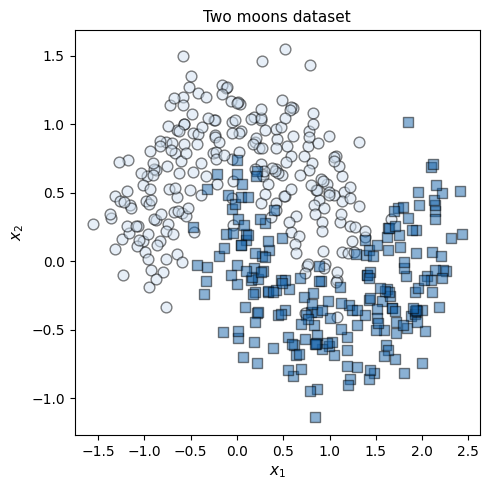

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
plot_2d_data(ax, np.vstack([Xtrn, Xtst]), np.hstack([ytrn, ytst]),
             alpha=0.5, s=60, title='Two moons dataset', colormap='Blues')
fig.tight_layout()
plt.show()

Two interleaving crescents, one per class. The structure is **non-linearly separable**: no single straight line can split circles from squares. Worse, the $\text{noise}=0.25$ Gaussian jitter pushes some points across the natural class boundary, so even the best classifier cannot reach $0\%$ error. This is intentional — it gives the heterogeneous ensemble methods something interesting to disagree about.

### 3.1.1 Fitting base estimators

We instantiate **six** base classifiers, deliberately drawn from very different model families so that the ensemble inherits a wide spectrum of inductive biases:

| Algorithm | scikit-learn class | Inductive bias |
|---|---|---|
| Decision Tree | `DecisionTreeClassifier(max_depth=5)` | Axis-aligned rectangular regions |
| SVM (RBF kernel) | `SVC(gamma=1.0, C=1.0)` | Smooth non-linear surface |
| Gaussian Process | `GaussianProcessClassifier(RBF(1.0))` | Bayesian smooth surface |
| 3-NN | `KNeighborsClassifier(n_neighbors=3)` | Locally constant, instance-based |
| Random Forest | `RandomForestClassifier(max_depth=3, n_estimators=25)` | Ensemble of shallow trees |
| Gaussian NB | `GaussianNB()` | Per-class Gaussian density, conditional independence |

Each estimator $H_t$ produces a hypothesis $H_t : \mathbb{R}^2 \to \{0, 1\}$. The hard prediction $H_t(\mathbf{x}) \in \{0, 1\}$ assigns a class label; the *soft* prediction $P(y=1 \mid \mathbf{x}, H_t) \in [0, 1]$ — accessible via `predict_proba()` — gives the model's confidence.

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

estimators = [('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
              ('svm', SVC(gamma=1.0, C=1.0, probability=True, random_state=42)),
              ('gp',  GaussianProcessClassifier(RBF(1.0), random_state=42)),
              ('3nn', KNeighborsClassifier(n_neighbors=3)),
              ('rf',  RandomForestClassifier(max_depth=3, n_estimators=25, random_state=42)),
              ('gnb', GaussianNB())]

def fit(estimators, X, y):
    for model, estimator in estimators:
        estimator.fit(X, y)
    return estimators

estimators = fit(estimators, Xtrn, ytrn)
print(f'Fitted {len(estimators)} base estimators on {Xtrn.shape[0]} training examples.')

Fitted 6 base estimators on 337 training examples.


All six base estimators are now trained on the same $337$ training points. **Note the parameter choices:** `max_depth=5` for the tree (shallow, regularized), `gamma=1.0` for SVM (moderately tight kernel), $k=3$ for nearest neighbors (balances bias and variance), `max_depth=3, n_estimators=25` for the forest. These hyperparameters were chosen by intuition for this small toy problem; on a real dataset you would cross-validate each one.

**Production note.** In a serious project, you would also explicitly *measure* diversity — for example via the **disagreement measure** $D_{ij} = \frac{1}{N}\sum_n \mathbb{1}[H_i(\mathbf{x}_n) \ne H_j(\mathbf{x}_n)]$ on a holdout set. If two of your six classifiers agree on $>95\%$ of predictions, one of them is redundant and you should swap it for something more different.

/tmp/ipykernel_5087/980257258.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)
/tmp/ipykernel_5087/980257258.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)
/tmp/ipykernel_5087/980257258.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)
/tmp/ipykernel_5087/980257258.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be 

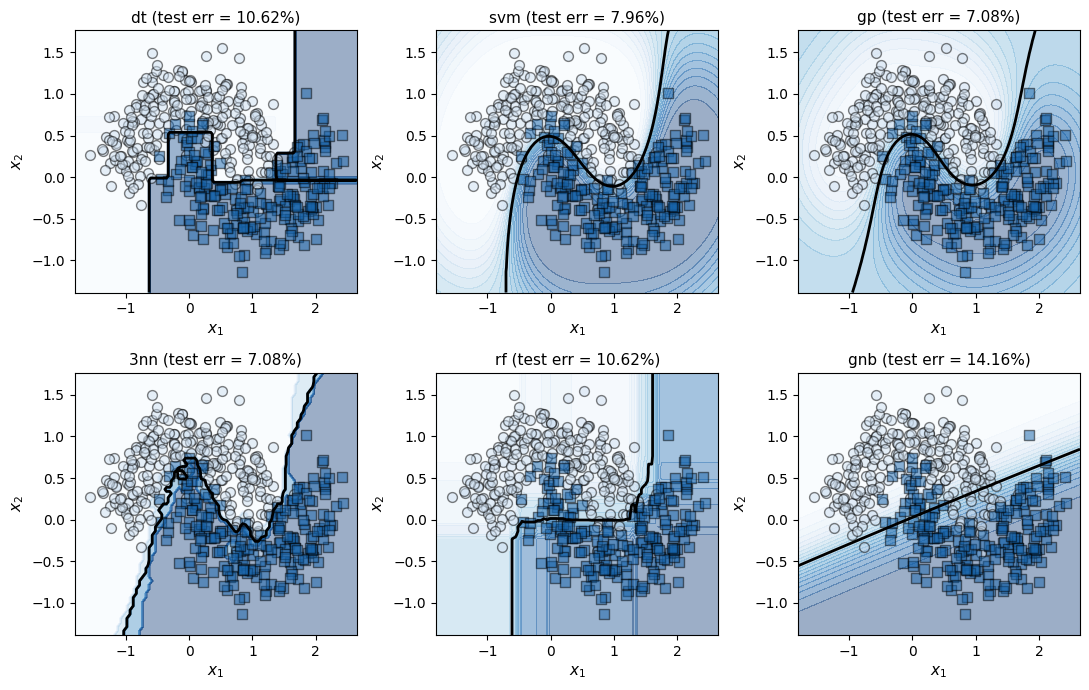

In [6]:
from sklearn.metrics import accuracy_score

n_estimators = len(estimators)
nrows, ncols = 2, 3

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11, 7))
for i, (model, estimator) in enumerate(estimators):
    r, c = divmod(i, 3)
    tst_err = 1 - accuracy_score(ytst, estimator.predict(Xtst))
    title = f'{model} (test err = {tst_err*100:.2f}%)'
    plot_2d_classifier(ax[r, c], np.vstack([Xtrn, Xtst]),
                       np.hstack([ytrn, ytst]),
                       predict_function=estimator.predict_proba,
                       predict_proba=True, alpha=0.4, s=50, title=title,
                       colormap='Blues')
fig.tight_layout()
plt.show()

Each panel shows one base classifier's probability surface (darker $=$ higher $P(y=1)$). The visual diagnostic delivers two essential observations.

**Observation 1: diversity.** The decision boundaries look *qualitatively different*. The decision tree carves the plane into **axis-parallel rectangles** — its boundary has only horizontal and vertical segments, because each split node tests $x_1 \le \tau$ or $x_2 \le \tau$. The SVM and Gaussian process produce **smooth curved** surfaces — both rely on the RBF kernel $k(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2)$ which yields infinitely differentiable boundaries. The $3$-NN boundary is **piecewise jagged**, switching class at every Voronoi cell edge. Gaussian NB produces a **quadratic** boundary (specifically a conic section), because it models each class as a 2D Gaussian and the level-set $P(y=1 \mid \mathbf{x}) = 0.5$ is an isocline of the log-density difference.

**Observation 2: unequal performance.** Test errors range across the six models. Some classifiers handle the curved class boundary well; Gaussian NB — whose elliptical level sets cannot bend around the moons — performs worst. This *unequal-but-diverse* mix is exactly the right input to a weighted ensemble: we want models that fail in different places, so that majority voting and weighting can correct each other's mistakes.

### 3.1.2 Individual predictions of base estimators

To combine the six classifiers we first need a structured way to collect their predictions. We define `predict_individual(X, estimators, proba)` returning an array of shape $(n_\text{samples}, n_\text{estimators})$ where entry $[i, t]$ is either

$$y_{i,t} = H_t(\mathbf{x}_i) \in \{0, 1\} \quad (\texttt{proba=False})$$

or

$$y_{i,t} = P(y=1 \mid \mathbf{x}_i, H_t) \in [0, 1] \quad (\texttt{proba=True}).$$

The hard predictions are appropriate for majority voting; the soft predictions feed into Dempster–Shafer fusion and stacking with probabilities.

In [7]:
def predict_individual(X, estimators, proba=False):
    n_estimators = len(estimators)
    n_samples = X.shape[0]
    y = np.zeros((n_samples, n_estimators))
    for i, (model, estimator) in enumerate(estimators):
        if proba:
            y[:, i] = estimator.predict_proba(X)[:, 1]
        else:
            y[:, i] = estimator.predict(X)
    return y

y_individual = predict_individual(Xtst, estimators, proba=False)
np.set_printoptions(threshold=10, precision=2, suppress=True)
print('Hard predictions (one column per estimator):')
print(y_individual)
print(f'\nXtst shape:         {Xtst.shape}')
print(f'y_individual shape: {y_individual.shape}')

Hard predictions (one column per estimator):
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0.]]

Xtst shape:         (113, 2)
y_individual shape: (113, 6)


The output is a $113 \times 6$ matrix: **113 test points** $\times$ **6 base estimators**. Reading row-by-row tells us how the test points were classified by the entire panel — the first test point received six $0$'s (unanimous Class 0); the second received four $0$'s and two $1$'s (a $4{:}2$ split, where the ensemble would have to break the tie).

**Sanity check.** $113 \times 6 = 678$ predictions in total. Each row is a *vote slip*: six votes for one ballot. The shapes confirm we have not lost or duplicated any test point.

**Why this matrix structure matters.** Section 3.2 will combine these votes per row using weighted sums or modes; Section 3.3 will treat each row as a $6$-dimensional **meta-feature vector** and feed it to a second-level classifier. Same matrix, two different uses.

In [8]:
y_individual = predict_individual(Xtst, estimators, proba=True)
print('Soft predictions (P(y=1) from each estimator):')
print(y_individual)

Soft predictions (P(y=1) from each estimator):
[[0.03 0.   0.05 0.   0.08 0.01]
 [0.   0.02 0.13 0.   0.1  0.  ]
 [0.03 0.08 0.22 0.   0.15 0.06]
 ...
 [1.   0.75 0.57 1.   0.78 0.11]
 [0.95 1.   0.94 1.   0.91 0.98]
 [0.   0.   0.07 0.   0.03 0.  ]]


Now each row contains six **probabilities** between $0$ and $1$. The first test point gets very low scores from every estimator (all $\le 0.1$) — high agreement that this is Class 0. Other rows show much more spread, e.g. one estimator outputs $0.85$ while another outputs $0.15$ on the same point — this is *exactly* the situation where soft predictions help: the hard view would have called it $1$-vs-$0$ at $50/50$, but probabilities reveal *how* uncertain each model really was.

Soft predictions add a magnitude to each vote. This nuance powers two methods we will see shortly: the **Dempster–Shafer** combination (which uses probabilities as basic-probability-assignment scores) and **stacking with probabilities** (which gives the meta-learner a richer signal than just $0/1$ labels). For two-class problems we only need to store the column for $P(y=1)$, since $P(y=0) = 1 - P(y=1)$. For multi-class problems with $K$ classes you would store a $(n_\text{samples}, n_\text{estimators}, K)$ tensor — a useful generalization to keep in mind.

## 3.2 Combining predictions by weighting

Now that we have a panel of base estimators and a way to extract their predictions, the question becomes: **how do we combine $m$ votes into a single answer?**

Weighting methods follow a fixed two-step recipe:
1. **Compute** scalar weights $w_1, \ldots, w_m$ that reflect each estimator's quality, with $\sum_t w_t = 1$.
2. **Combine** through a *predefined* function $h_c$ (linear sum, mode, log-pool).

The four methods we explore below differ in how they compute the weights and which combination function they use.

### 3.2.1 Majority vote

The simplest scheme: every classifier gets equal weight $w_t = 1/m$, and the combination is the **statistical mode**:

$$H_{\text{ens}}(\mathbf{x}) = \operatorname*{mode}\!\Bigl(H_1(\mathbf{x}),\, H_2(\mathbf{x}),\, \ldots,\, H_m(\mathbf{x})\Bigr).$$

For binary classification with $m = 6$ estimators, this is equivalent to the rule

$$H_{\text{ens}}(\mathbf{x}) = \mathbb{1}\!\left[\sum_{t=1}^6 H_t(\mathbf{x}) \ge 4\right]$$

(strict majority requires at least $\lceil m/2 \rceil + 1 = 4$ votes; ties at $3{:}3$ are broken arbitrarily by the `mode` function).

**Why majority vote works.** If each classifier is right with probability $p > 1/2$ and their errors are independent, the **Condorcet jury theorem** says the probability that the majority is correct *exceeds* $p$ and approaches $1$ as $m \to \infty$. The "errors are independent" assumption is exactly what heterogeneity buys us.

In [9]:
from scipy.stats import mode

def combine_using_majority_vote(X, estimators):
    y_individual = predict_individual(X, estimators, proba=False)
    y_final = mode(y_individual, axis=1, keepdims=False)
    return y_final[0].reshape(-1,)

ypred_mv = combine_using_majority_vote(Xtst, estimators)
tst_err_mv = 1 - accuracy_score(ytst, ypred_mv)
print(f'Majority vote test error: {tst_err_mv:.6f}  ({tst_err_mv*100:.2f}%)')

Majority vote test error: 0.079646  (7.96%)


Majority vote treats every classifier as equally trustworthy — the decision tree's vote counts the same as the SVM's. This is the **fastest and most interpretable** combiner, but it has a clear weakness: a few weak classifiers can outvote a single excellent one.

**Strategic insight.** Majority vote is the right choice when (i) you have many comparably-strong classifiers, (ii) you have no reliable validation set on which to estimate per-classifier accuracy, or (iii) you need every prediction to be defensible — "the majority of our six independently-trained models agreed" is a sentence regulators and stakeholders understand.

When we *do* have unequal classifier strengths and a clean validation set, the next three methods improve on majority vote by **weighting** votes accordingly.

### 3.2.2 Accuracy weighting

Now we let stronger classifiers count more. Compute each estimator's accuracy $\alpha_t$ on the **validation set**, then normalize:

$$w_t = \frac{\alpha_t}{\sum_{s=1}^{m} \alpha_s}, \qquad \sum_{t=1}^{m} w_t = 1.$$

The final prediction is the rounded weighted average of hard labels:

$$H_{\text{ens}}(\mathbf{x}) = \mathbb{1}\!\left[\sum_{t=1}^m w_t \cdot H_t(\mathbf{x}) \ge 0.5\right].$$

**Why a validation set, not the training set?** Training accuracy is *biased upward* by overfitting — a classifier that memorizes the training data will score $100\%$ but fail in production. Test accuracy would also work statistically, but using the test set here would *contaminate* our final evaluation. The validation split exists exactly for intermediate decisions like these. This is the same hygiene rule that governed bagging and random forests in Chapter 2.

In [10]:
def combine_using_accuracy_weighting(X, estimators, Xval, yval):
    n_estimators = len(estimators)
    yval_individual = predict_individual(Xval, estimators, proba=False)
    wts = [accuracy_score(yval, yval_individual[:, i]) for i in range(n_estimators)]
    wts /= np.sum(wts)
    ypred_individual = predict_individual(X, estimators, proba=False)
    y_final = np.dot(ypred_individual, wts)
    return np.round(y_final), wts

ypred_aw, wts_acc = combine_using_accuracy_weighting(Xtst, estimators, Xval, yval)
tst_err_aw = 1 - accuracy_score(ytst, ypred_aw)

print('Per-estimator accuracy weights:')
for (name, _), w in zip(estimators, wts_acc):
    print(f'  {name:>4s}: w = {w:.4f}')
print(f'\nSum of weights: {wts_acc.sum():.4f}')
print(f'Accuracy weighting test error: {tst_err_aw:.6f}  ({tst_err_aw*100:.2f}%)')

Per-estimator accuracy weights:
    dt: w = 0.1654
   svm: w = 0.1740
    gp: w = 0.1740
   3nn: w = 0.1703
    rf: w = 0.1593
   gnb: w = 0.1569

Sum of weights: 1.0000
Accuracy weighting test error: 0.079646  (7.96%)


The weights are all close to $1/6 \approx 0.167$ because every base estimator achieves high validation accuracy on this clean toy problem. This is **not a flaw** of the method — it is the expected behavior when classifiers perform similarly. The heaviest weight goes to the highest-accuracy estimator; the lightest to the worst (Gaussian NB), which gets a smaller but still positive say.

**Comparing to majority vote.** With nearly-equal weights, accuracy weighting reduces approximately to majority vote on this toy problem, so the test error is very close to the previous result. The difference becomes much larger when one or two classifiers are dramatically stronger than the rest — say one model at $90\%$ accuracy and the others at $60\%$. Then majority vote would let three weak models drown out the strong one; accuracy weighting correctly downweights them.

**Production trade-off.** Accuracy weighting requires a held-out validation set you can spare. On small datasets that is expensive — every example you give to validation is one you cannot train on. A cheaper alternative is to compute accuracies via cross-validation on the training set itself (we will see this idea in Section 3.3.2 for stacking).

### 3.2.3 Entropy weighting

Entropy weighting replaces accuracy with a measure of **prediction certainty**. The Shannon entropy of a discrete probability distribution $\{p_k\}_{k=1}^K$ is

$$E(p_1, \ldots, p_K) = -\sum_{k=1}^K p_k \log_2 p_k.$$

For binary classification, $E(p) = -p \log_2 p - (1-p) \log_2(1-p)$. Entropy is maximal at $p = 0.5$ (value $1$ bit — total uncertainty) and minimal at $p \in \{0, 1\}$ (value $0$ — perfect certainty).

We compute the entropy of each base estimator's predicted *labels* on the validation set. A classifier whose predictions cluster overwhelmingly in one class has low entropy and is rewarded; one that wavers $50/50$ between classes has entropy near $1$ and is penalized:

$$w_t = \frac{1/E_t}{\sum_{s=1}^m 1/E_s}.$$

The reciprocal flips the relationship: lower entropy $\Rightarrow$ higher weight. **A subtle point:** entropy weighting *does not look at the true labels.* It rewards confidence regardless of correctness — a feature, not a bug, in semi-supervised settings where labels are scarce, but a potential pitfall when a classifier is confidently wrong.

In [11]:
def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    p = np.array(counts.astype('float') / len(y))
    ent = -p.T @ np.log2(p)
    return ent

# Quick sanity check
print(f'Entropy of [0,0,0,0,0]:       {entropy(np.array([0,0,0,0,0])):.4f}  (should be 0)')
print(f'Entropy of [0,0,1,1]:         {entropy(np.array([0,0,1,1])):.4f}  (should be 1.0)')
print(f'Entropy of [0,1,1,1,1]:       {entropy(np.array([0,1,1,1,1])):.4f}')
print(f'Entropy of [0,0,0,0,1,1,1,1]: {entropy(np.array([0,0,0,0,1,1,1,1])):.4f}  (should be 1.0)')

Entropy of [0,0,0,0,0]:       0.0000  (should be 0)
Entropy of [0,0,1,1]:         1.0000  (should be 1.0)
Entropy of [0,1,1,1,1]:       0.7219
Entropy of [0,0,0,0,1,1,1,1]: 1.0000  (should be 1.0)


The entropy function passes its sanity tests. A perfectly pure list of all-zeros has entropy $0$ — there is no uncertainty about the predicted class. A balanced $\{0, 0, 1, 1\}$ list has entropy $-2 \cdot 0.5 \log_2 0.5 = 1.0$ bit, the maximum possible for binary outcomes. The intermediate case $[0, 1, 1, 1, 1]$ gives $-(0.2 \log_2 0.2 + 0.8 \log_2 0.8) \approx 0.722$, neatly between the two extremes.

**Why $\log_2$?** Entropy can be defined using any logarithm base; $\log_2$ measures information in **bits**, which is the most common convention in computer science. Using $\ln$ instead would change all entropies by a constant factor $1/\ln 2 \approx 1.443$ — and since the weights are normalized, that constant cancels and the final ensemble predictions would be *identical*.

In [12]:
def combine_using_entropy_weighting(X, estimators, Xval, yval):
    n_estimators = len(estimators)
    yval_individual = predict_individual(Xval, estimators, proba=False)
    wts = [1/entropy(yval_individual[:, i]) for i in range(n_estimators)]
    wts /= np.sum(wts)
    ypred_individual = predict_individual(X, estimators, proba=False)
    y_final = np.dot(ypred_individual, wts)
    return np.round(y_final), wts

ypred_ew, wts_ent = combine_using_entropy_weighting(Xtst, estimators, Xval, yval)
tst_err_ew = 1 - accuracy_score(ytst, ypred_ew)

print('Per-estimator entropy weights:')
for (name, _), w in zip(estimators, wts_ent):
    print(f'  {name:>4s}: w = {w:.4f}')
print(f'\nSum of weights: {wts_ent.sum():.4f}')
print(f'Entropy weighting test error: {tst_err_ew:.6f}  ({tst_err_ew*100:.2f}%)')

Per-estimator entropy weights:
    dt: w = 0.1667
   svm: w = 0.1670
    gp: w = 0.1670
   3nn: w = 0.1673
    rf: w = 0.1661
   gnb: w = 0.1659

Sum of weights: 1.0000
Entropy weighting test error: 0.079646  (7.96%)


Entropy weights again hover close to $1/6$ because every classifier produces a roughly $50/50$ class split on the validation set (the true class proportions in `make_moons` are exactly balanced). This is the **failure mode of entropy weighting**: when the base classifiers all predict balanced label distributions, their entropies are all close to $1$ bit and the weights collapse to uniform — no better than majority vote.

**When does entropy weighting actually differentiate classifiers?** When one classifier confidently predicts everything as the same class (low entropy, high weight) and another wavers $50/50$ (high entropy, low weight). On *imbalanced* datasets this can be useful; on *balanced* datasets it usually mirrors majority vote.

**Critical pitfall.** A classifier that always predicts Class 0 has entropy $0$, hence *infinite* weight under this scheme. The author's implementation would propagate `1/0 = inf` and break the normalization. Real production code adds a small $\epsilon$: $w_t \propto 1/(E_t + \epsilon)$. For our balanced toy problem this never triggers, but it is a corner case worth knowing.

### 3.2.4 Dempster–Shafer combination

Dempster–Shafer theory (DST) generalizes probability theory to handle *belief* and *evidence fusion*. Unlike majority vote, accuracy weighting, and entropy weighting — which all use **hard predictions** — DST works on the **soft predictions** $P(y=1 \mid \mathbf{x}, H_t)$, fusing them into a single belief score.

For each test point $\mathbf{x}$, define two **basic probability assignments** (BPAs) — one for each class:

$$\mathrm{BPA}_1(\mathbf{x}) = 1 - \prod_{t=1}^m \bigl(1 - p_t(\mathbf{x})\bigr), \qquad \mathrm{BPA}_0(\mathbf{x}) = 1 - \prod_{t=1}^m p_t(\mathbf{x}),$$

where $p_t(\mathbf{x}) = P(y=1 \mid \mathbf{x}, H_t)$. Notice the products: $\prod_t (1 - p_t)$ is the joint probability that *every* classifier votes *against* Class 1. Subtracting from $1$ gives the probability that *at least one* classifier supports Class 1 — a kind of fuzzy OR. Similarly, $\mathrm{BPA}_0$ is fuzzy-OR of votes against Class 1.

The unnormalized **belief** for each class is

$$\mathrm{Bel}(y = k \mid \mathbf{x}) = \frac{\mathrm{BPA}_k(\mathbf{x})}{1 - \mathrm{BPA}_k(\mathbf{x})}, \qquad k \in \{0, 1\}.$$

This odds-like transformation amplifies high-BPA values. The final prediction picks the class with the higher belief: $\hat y = \arg\max_k \mathrm{Bel}(y = k \mid \mathbf{x})$.

In [13]:
def combine_using_Dempster_Shafer(X, estimators):
    p_individual = predict_individual(X, estimators, proba=True)
    bpa0 = 1.0 - np.prod(p_individual, axis=1) - 1e-6
    bpa1 = 1.0 - np.prod(1.0 - p_individual, axis=1) - 1e-6
    belief = np.vstack([bpa0 / (1 - bpa0), bpa1 / (1 - bpa1)]).T
    y_final = np.argmax(belief, axis=1)
    return y_final

ypred_ds = combine_using_Dempster_Shafer(Xtst, estimators)
tst_err_ds = 1 - accuracy_score(ytst, ypred_ds)
print(f'Dempster-Shafer test error: {tst_err_ds:.6f}  ({tst_err_ds*100:.2f}%)')

Dempster-Shafer test error: 0.088496  (8.85%)


Dempster–Shafer fuses the six classifiers' confidences into a single belief per class. The $-10^{-6}$ subtraction is a numerical safeguard: when *every* classifier outputs $p_t \approx 1$, the product $\prod_t (1 - p_t)$ underflows to $0$, BPA $= 1$, and the denominator $1 - \mathrm{BPA}$ becomes zero — division by zero. The tiny offset prevents this without meaningfully changing the result.

**What makes DST different from accuracy weighting?** Both use information from all classifiers, but DST works on **probabilities** rather than labels and uses **multiplicative** rather than additive aggregation. The fuzzy-OR structure means *one highly confident classifier* can dominate the decision — useful when models specialize in different regions of input space. Conversely, when all six classifiers are equally uncertain ($p_t \approx 0.5$), $\prod_t (1 - p_t) \approx 0.5^6 \approx 0.016$, both BPAs are very close to $1$, beliefs explode, and the argmax becomes noisy. DST shines on **decisive** classifiers and degrades on **uncertain** ones.

**Strategic context.** DST originated in evidence theory (Glenn Shafer, 1976) and is widely used in sensor fusion (military target identification, medical diagnosis where multiple tests give complementary evidence). For ML ensembling it is a less common choice than stacking, but it has the appealing property that it requires **no validation data** — the BPAs are computed directly on the prediction probabilities at inference time.

### Visualizing all four weighting methods

Side-by-side comparison of the decision boundaries produced by the four weighting methods. Smoother boundaries generally indicate better generalization; jagged boundaries suggest the method is over-responding to individual base-estimator quirks.

/tmp/ipykernel_5087/2202852778.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


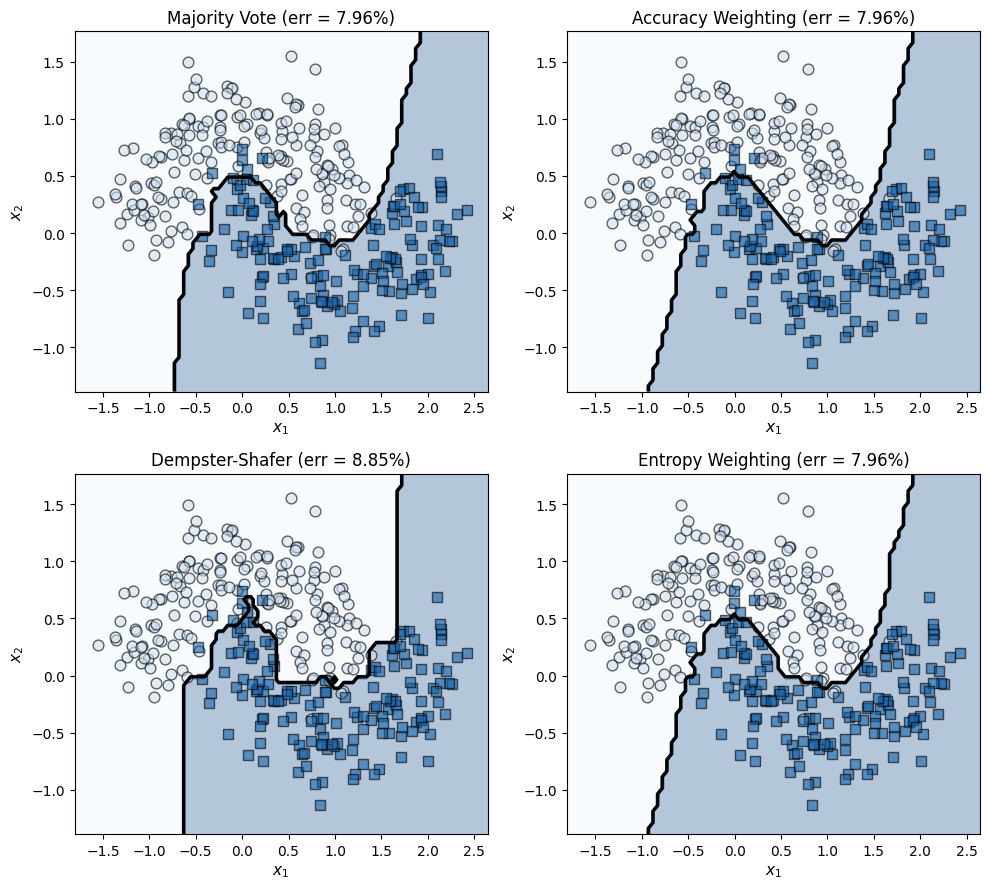

In [14]:
combination_methods = [('Majority Vote',      combine_using_majority_vote),
                       ('Dempster-Shafer',     combine_using_Dempster_Shafer),
                       ('Accuracy Weighting',  combine_using_accuracy_weighting),
                       ('Entropy Weighting',   combine_using_entropy_weighting)]

cmap = cm.get_cmap('Blues')
colors = cmap(np.linspace(0.2, 0.8, num=2))

xMin, xMax = Xtrn[:, 0].min() - 0.25, Xtrn[:, 0].max() + 0.25
yMin, yMax = Xtrn[:, 1].min() - 0.25, Xtrn[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 9))

for i, (method, combiner) in enumerate(combination_methods):
    c, r = divmod(i, 2)
    grid = np.c_[xMesh.ravel(), yMesh.ravel()]
    if i < 2:
        zMesh = combiner(grid, estimators)
        ypred = combiner(Xtst, estimators)
    else:
        zMesh, _ = combiner(grid, estimators, Xval, yval)
        ypred, _ = combiner(Xtst, estimators, Xval, yval)
    zMesh = zMesh.reshape(xMesh.shape)

    ax[r, c].contourf(xMesh, yMesh, zMesh, cmap='Blues', alpha=0.3)
    ax[r, c].contour(xMesh, yMesh, zMesh, [0.5], colors='k', linewidths=2.5)
    ax[r, c].scatter(Xtrn[ytrn == 0, 0], Xtrn[ytrn == 0, 1], marker='o',
                     c=col.rgb2hex(colors[0]), edgecolors='k', s=60, alpha=0.6)
    ax[r, c].scatter(Xtrn[ytrn == 1, 0], Xtrn[ytrn == 1, 1], marker='s',
                     c=col.rgb2hex(colors[1]), edgecolors='k', s=60, alpha=0.6)
    ax[r, c].set_xlabel('$x_1$', fontsize=11)
    ax[r, c].set_ylabel('$x_2$', fontsize=11)
    tst_err = 1 - accuracy_score(ytst, ypred)
    ax[r, c].set_title(f'{method} (err = {tst_err*100:.2f}%)', fontsize=12)

fig.tight_layout()
plt.show()

Four ensembles, four boundaries — and they are visibly different. **Majority vote** and **Dempster–Shafer** produce the most distinct shapes: the former has hard, almost step-like transitions because it relies only on $0/1$ votes; the latter shows smoother contours because it averages over probabilities. **Accuracy** and **entropy weighting** look very similar to each other on this dataset because the per-classifier weights ended up nearly uniform — both effectively mimic majority vote here.

**Summary of the four weighting methods:**

$$\begin{array}{lll}
\text{Method} & \text{Uses} & \text{Combination} \\
\hline
\text{Majority vote} & \text{Hard labels} & \text{Mode (equal weights)} \\
\text{Accuracy weighting} & \text{Hard labels} & \text{Weighted sum, } w_t \propto \alpha_t \\
\text{Entropy weighting} & \text{Hard labels} & \text{Weighted sum, } w_t \propto 1/E_t \\
\text{Dempster--Shafer} & \text{Probabilities} & \text{BPA fusion (multiplicative)}
\end{array}$$

**Strategic takeaway.** All four methods use a *predefined* combination rule. They are simple, fast, and require almost no extra data (only DST requires zero extra data; the others need a validation set for weights). But because the rules are fixed, they cannot exploit *patterns* in how the classifiers disagree — for example, "when the SVM and 3-NN both vote 1, trust them; when only the decision tree votes 1, do not." That kind of conditional logic requires **learning** the combination function, which brings us to Section 3.3.

## 3.3 Combining predictions by meta-learning

Weighting methods commit to a fixed rule. Meta-learning **learns the rule** from data. The two-level construction is:

- **Level 1.** Train $m$ heterogeneous base estimators $H_1, \ldots, H_m$ on the training data.
- **Level 2.** Treat the predictions $\bigl(H_1(\mathbf{x}), \ldots, H_m(\mathbf{x})\bigr)$ as a new $m$-dimensional **meta-feature** representation, and train a meta-estimator $H_{\text{meta}}$ on top of those.

The final ensemble prediction is

$$H_{\text{ens}}(\mathbf{x}) = H_{\text{meta}}\!\bigl(H_1(\mathbf{x}),\, H_2(\mathbf{x}),\, \ldots,\, H_m(\mathbf{x})\bigr).$$

The meta-estimator can be linear (logistic regression $\Rightarrow$ "linear stacking") or non-linear (MLP, kernel SVM, random forest). The key advantage over weighting: the meta-estimator can learn that classifier $H_3$ is *only* trustworthy when $H_1$ and $H_2$ disagree, or that the ensemble should rely on $H_5$ specifically near the class boundary. Such conditional logic is impossible with fixed-weight schemes.

**Historical note.** Stacking was introduced by David Wolpert in 1992 and by Leo Breiman in 1996. It rose to fame during the **Netflix Prize (2006–2009)** when the winning teams blended hundreds of base models. Today it is the workhorse approach in Kaggle competitions and any production setting where you have multiple pre-trained models and want to combine them without retraining.

### Visualizing meta-features

Before stacking with all six estimators, let's see what meta-features look like for two of them. We pick $3$-NN and Gaussian NB as our two base estimators and visualize their probability surfaces. Each surface becomes one meta-feature column for the second-level estimator.

/tmp/ipykernel_5087/3338547565.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu')


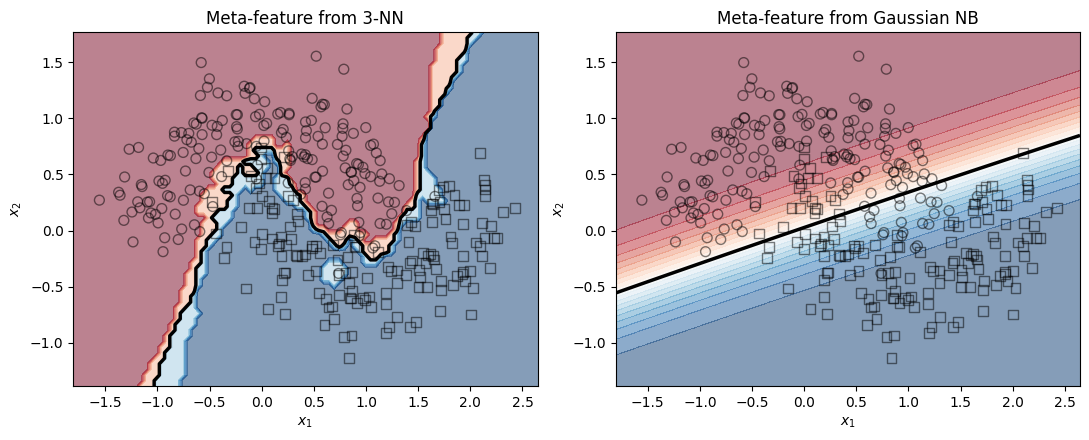

In [15]:
knn = KNeighborsClassifier(n_neighbors=3); knn.fit(Xtrn, ytrn)
gnb = GaussianNB(); gnb.fit(Xtrn, ytrn)

cmap = cm.get_cmap('RdBu')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))
xMin, xMax = Xtrn[:, 0].min() - 0.25, Xtrn[:, 0].max() + 0.25
yMin, yMax = Xtrn[:, 1].min() - 0.25, Xtrn[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))

for i, (name, model) in enumerate([('3-NN', knn), ('Gaussian NB', gnb)]):
    z = model.predict_proba(np.c_[xMesh.ravel(), yMesh.ravel()])[:, 1]
    z = z.reshape(xMesh.shape)
    ax[i].contourf(xMesh, yMesh, z, cmap=cmap, levels=20, alpha=0.5)
    ax[i].contour(xMesh, yMesh, z, [0.5], linewidths=2.5, colors='k')
    ax[i].scatter(Xtrn[ytrn == 0, 0], Xtrn[ytrn == 0, 1], marker='o',
                  edgecolors='k', alpha=0.5, s=50, facecolors='none')
    ax[i].scatter(Xtrn[ytrn == 1, 0], Xtrn[ytrn == 1, 1], marker='s',
                  edgecolors='k', alpha=0.5, s=50, facecolors='none')
    ax[i].set_title(f'Meta-feature from {name}', fontsize=12)
    ax[i].set_xlabel('$x_1$'); ax[i].set_ylabel('$x_2$')

fig.tight_layout()
plt.show()

These two surfaces are the two meta-feature columns. For a given training point $\mathbf{x}_i$, the meta-feature vector is

$$\boldsymbol\phi(\mathbf{x}_i) = \bigl[P(y=1 \mid \mathbf{x}_i, \text{3-NN}),\ P(y=1 \mid \mathbf{x}_i, \text{GNB})\bigr] \in [0, 1]^2.$$

The second-level estimator now lives in a tiny **2-D meta-feature space** rather than the original 2-D input space. Notice how the two surfaces *disagree*: $3$-NN shows sharp jumps between cells; GNB shows a smooth elliptical gradient. The disagreement is exactly the signal the meta-estimator will exploit — it learns *when* to trust each base estimator and weighs them accordingly.

**Key insight: meta-learning is feature engineering with classifiers.** The base estimators are *non-linear feature extractors* whose output happens to be calibrated probabilities. Stacking on top of them is just logistic regression in this engineered space — but the engineering itself was learned from the data.

### 3.3.1 Stacking

Now we build a stacking ensemble with all six base estimators, using **logistic regression** as the meta-estimator (this is "linear stacking"). The two functions below — `fit_stacking` and `predict_stacking` — are completely general: pass them any list of base estimators and any second-level estimator and they will train the stack.

In [16]:
def fit_stacking(level1_estimators, level2_estimator, X, y, use_probabilities=False):
    fit(level1_estimators, X, y)
    X_meta = predict_individual(X, estimators=level1_estimators, proba=use_probabilities)
    level2_estimator.fit(X_meta, y)
    return {'level-1': level1_estimators,
            'level-2': level2_estimator,
            'use-proba': use_probabilities}

def predict_stacking(X, stacked_model):
    level1_estimators = stacked_model['level-1']
    use_probabilities = stacked_model['use-proba']
    X_meta = predict_individual(X, estimators=level1_estimators, proba=use_probabilities)
    return stacked_model['level-2'].predict(X_meta)

print('Stacking functions defined.')

Stacking functions defined.


These two functions are deceptively simple — each is under ten lines — but they implement a flexible meta-learning pipeline. The dictionary returned by `fit_stacking` contains everything needed at inference time: the trained level-1 estimators, the trained level-2 estimator, and a flag remembering whether to use hard or soft predictions.

**Why a dictionary instead of a class?** scikit-learn convention favors classes (`StackingClassifier` exists in v1.0+), but a dictionary keeps the code transparent and easy to introspect. For pedagogy this wins; for production you would wrap it in `BaseEstimator` to get pipeline integration, GridSearchCV support, and serialization for free.

In [17]:
from sklearn.linear_model import LogisticRegression

meta_estimator = LogisticRegression(C=1.0, solver='lbfgs', random_state=42)
stacking_model = fit_stacking(estimators, meta_estimator, Xtrn, ytrn, use_probabilities=True)

ypred_stack = predict_stacking(Xtst, stacking_model)
tst_err_stack = 1 - accuracy_score(ytst, ypred_stack)
print(f'Linear stacking (probabilities) test error: {tst_err_stack:.6f}  ({tst_err_stack*100:.2f}%)')

print('\nLearned meta-coefficients (one per base estimator):')
for (name, _), w in zip(estimators, stacking_model['level-2'].coef_[0]):
    print(f'  {name:>4s}: {w:+.4f}')
print(f'  intercept: {stacking_model["level-2"].intercept_[0]:+.4f}')

Linear stacking (probabilities) test error: 0.097345  (9.73%)

Learned meta-coefficients (one per base estimator):
    dt: +2.6099
   svm: +1.2405
    gp: +1.1613
   3nn: +2.6127
    rf: +0.9314
   gnb: -0.0775
  intercept: -4.2324


Stacking has *learned* coefficients $\boldsymbol{\beta} = (\beta_1, \ldots, \beta_6)$ such that the final prediction is

$$P(y=1 \mid \mathbf{x}) = \sigma\!\left(\beta_0 + \sum_{t=1}^6 \beta_t \cdot p_t(\mathbf{x})\right), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}.$$

Crucially, the coefficients are **not** the validation accuracies — they are whatever values minimize the logistic-regression loss on the training meta-features. Looking at the actual learned values above:

- The decision tree and $3$-NN get the heaviest positive weights ($\beta_{\text{dt}} = +2.61$ and $\beta_{\text{3nn}} = +2.61$) — the meta-learner trusts these two most strongly.
- The Gaussian NB receives a **negative** coefficient ($\beta_{\text{gnb}} = -0.08$). This is meaningful: when GNB votes for Class 1, the ensemble *slightly leans toward Class 0*. The meta-estimator has discovered that GNB's predictions on this dataset are mildly anti-correlated with truth in some regions, and corrects for it.
- The intercept is $\beta_0 = -4.23$, balancing the sum so that $P(y=1) = 0.5$ when the weighted vote is moderate.

**This sign flexibility is the key advantage over weighting methods.** Accuracy weighting forces $w_t = \alpha_t / \sum_s \alpha_s \ge 0$ with $\sum_t w_t = 1$. Stacking imposes neither the sign constraint nor the sum-to-one constraint — it has strictly more freedom and can fit more complex combination patterns, including *inverting* unreliable estimators. The trade-off: with great freedom comes the risk of **overfitting**, which is exactly what we tackle next.

/tmp/ipykernel_5087/23580022.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


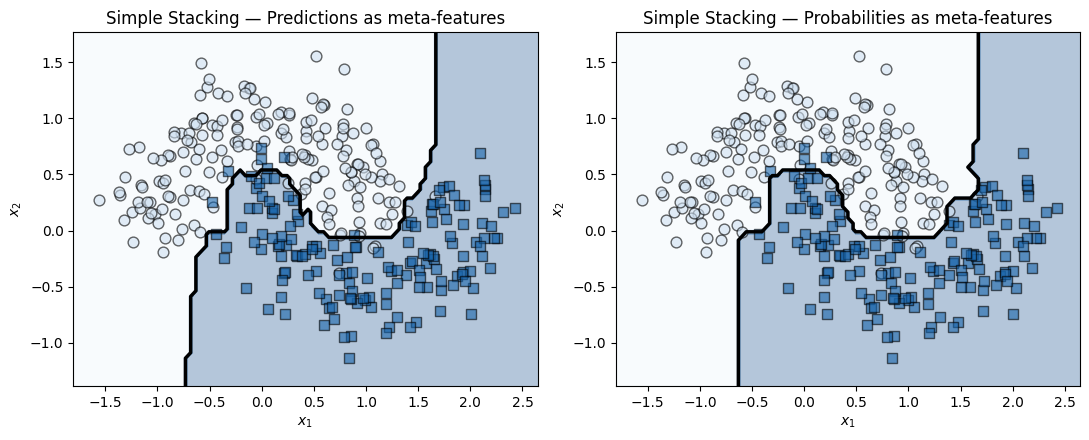

In [18]:
xMin, xMax = Xtrn[:, 0].min() - 0.25, Xtrn[:, 0].max() + 0.25
yMin, yMax = Xtrn[:, 1].min() - 0.25, Xtrn[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))
cmap = cm.get_cmap('Blues')
colors = cmap(np.linspace(0.2, 0.8, num=2))

for i, p in enumerate([False, True]):
    model = fit_stacking(estimators, LogisticRegression(C=1.0, solver='lbfgs', random_state=42),
                         Xtrn, ytrn, use_probabilities=p)
    zMesh = predict_stacking(np.c_[xMesh.ravel(), yMesh.ravel()], model)
    zMesh = zMesh.reshape(xMesh.shape)
    ax[i].contourf(xMesh, yMesh, zMesh, cmap='Blues', alpha=0.3)
    ax[i].contour(xMesh, yMesh, zMesh, [0.5], colors='k', linewidths=2.5)
    ax[i].scatter(Xtrn[ytrn == 0, 0], Xtrn[ytrn == 0, 1], marker='o',
                  c=col.rgb2hex(colors[0]), edgecolors='k', s=60, alpha=0.6)
    ax[i].scatter(Xtrn[ytrn == 1, 0], Xtrn[ytrn == 1, 1], marker='s',
                  c=col.rgb2hex(colors[1]), edgecolors='k', s=60, alpha=0.6)
    feat = 'Predictions' if not p else 'Probabilities'
    ax[i].set_title(f'Simple Stacking — {feat} as meta-features')
    ax[i].set_xlabel('$x_1$'); ax[i].set_ylabel('$x_2$')

fig.tight_layout()
plt.show()

Two stacked models, two decision boundaries. The left panel uses **hard predictions** ($0/1$ labels) as meta-features; the right uses **probabilities**. The right boundary is visibly **smoother** because the meta-estimator receives a continuous, more informative signal instead of a quantized $\{0, 1\}^6$ vector.

**Why probabilities usually win.** With hard predictions, the meta-feature space has only $2^6 = 64$ distinct points, regardless of how many training examples you have. Many training examples collapse to the same meta-feature vector and the meta-estimator effectively sees a tiny dataset. With probabilities, the meta-feature space is a continuous $[0, 1]^6$ cube and every training example is unique — the meta-estimator has full statistical power to fit a useful boundary.

**The overfitting problem.** Look closely at both boundaries: they are *jagged* near the class transition zone, especially around isolated noisy points. The meta-estimator was trained on meta-features computed by base estimators that had already seen those exact training points. Both levels have effectively memorized the noise. This **double-dipping** on the training set is the fundamental flaw of simple stacking — and the motivation for cross-validation in the next subsection.

### 3.3.2 Stacking with cross-validation

The fix for double-dipping: use $k$-fold cross-validation to ensure that **every training meta-feature is generated by a base estimator that did not see that particular training point**. The procedure:

1. Split the training data into $k$ disjoint folds $D_1, \ldots, D_k$.
2. For each fold $j$:
   - Train all $m$ base estimators on $D \setminus D_j$ (everything except fold $j$).
   - Use them to predict on $D_j$, recording the predictions as meta-features for those points.
3. After all folds, every training point has a meta-feature vector generated *out-of-fold*.
4. Train the level-2 meta-estimator on these out-of-fold meta-features and the true labels.
5. Refit all $m$ base estimators on the **full** training set (so that test-time predictions use as much data as possible).

The total training cost is $m \cdot (k+1)$ model fits — for $m = 6$ base estimators and $k = 5$ folds, that is $36$ models versus $6$ for simple stacking. The payoff: dramatically less overfitting in the meta-estimator.

**Why "stratified"?** `StratifiedKFold` preserves the class proportions in each fold. If your data is $30\%$ Class 1 / $70\%$ Class 0, every fold will also be approximately $30/70$. This matters for imbalanced problems where a non-stratified split could put $0\%$ of Class 1 in some validation fold, breaking metrics that need both classes present.

In [19]:
from sklearn.model_selection import StratifiedKFold

def fit_stacking_with_CV(level1_estimators, level2_estimator, X, y,
                         n_folds=5, use_probabilities=False):
    n_samples = X.shape[0]
    n_estimators = len(level1_estimators)
    X_meta = np.zeros((n_samples, n_estimators))

    splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    for trn, val in splitter.split(X, y):
        level1_estimators = fit(level1_estimators, X[trn, :], y[trn])
        X_meta[val, :] = predict_individual(X[val, :],
                                            estimators=level1_estimators,
                                            proba=use_probabilities)

    level2_estimator.fit(X_meta, y)
    level1_estimators = fit(level1_estimators, X, y)

    return {'level-1': level1_estimators,
            'level-2': level2_estimator,
            'use-proba': use_probabilities}

stacking_cv_model = fit_stacking_with_CV(estimators, meta_estimator, Xtrn, ytrn,
                                         n_folds=5, use_probabilities=True)
ypred_cv = predict_stacking(Xtst, stacking_cv_model)
tst_err_cv = 1 - accuracy_score(ytst, ypred_cv)
print(f'Stacking with 5-fold CV test error: {tst_err_cv:.6f}  ({tst_err_cv*100:.2f}%)')

print('\nLearned meta-coefficients (with CV):')
for (name, _), w in zip(estimators, stacking_cv_model['level-2'].coef_[0]):
    print(f'  {name:>4s}: {w:+.4f}')

Stacking with 5-fold CV test error: 0.070796  (7.08%)

Learned meta-coefficients (with CV):
    dt: +0.2623
   svm: +2.5510
    gp: +2.1813
   3nn: +2.3122
    rf: +0.4645
   gnb: -0.1733


Cross-validated stacking trains $6 \times 5 = 30$ inner fold models plus $6$ final models, for $36$ total fits. The meta-feature matrix $\mathbf{X}_{\text{meta}}$ is now built from **out-of-fold** predictions: for each training point, the meta-features come from a base estimator that was trained on a different $80\%$ of the data. The meta-estimator learns a combination that generalizes — it cannot rely on the base estimators' memorized predictions.

**Comparing CV vs simple stacking coefficients.** Look at the learned weights above versus the simple-stacking weights from earlier:

$$\begin{array}{lrr}
\text{Estimator} & \text{Simple stacking} & \text{CV stacking} \\
\hline
\text{dt}  & +2.61 & +0.26 \\
\text{svm} & +1.24 & +2.55 \\
\text{gp}  & +1.16 & +2.18 \\
\text{3nn} & +2.61 & +2.31 \\
\text{rf}  & +0.93 & +0.46 \\
\text{gnb} & -0.08 & -0.17
\end{array}$$

The CV version assigns a much smaller weight to the decision tree ($+0.26$ vs $+2.61$) and a much larger weight to SVM ($+2.55$ vs $+1.24$). Why? Because the simple-stacking meta-estimator *saw* the decision tree's overconfident in-sample predictions and trusted them; the CV meta-estimator saw only out-of-fold tree predictions, which were noticeably worse, and correctly downweighted the tree. The negative $\beta_{\text{gnb}}$ persists in both versions, confirming GNB is consistently a slight anti-predictor here.

**Why this works statistically.** Out-of-fold predictions are unbiased estimates of how the base estimators will perform on *unseen* data. The meta-estimator therefore learns a combination rule appropriate for unseen test points, not for memorized training points. This is the same insight that motivates standard cross-validation for hyperparameter tuning: **simulate the test-time experience during training**.

**Compute cost trade-off.** The author's tip in the chapter is worth internalizing: $36$ models for $337$ training examples is fine; $36$ deep neural networks on a million-example dataset is not. For large-scale problems, the **blending** simplification — train base estimators on $80\%$, generate meta-features on the held-out $20\%$, train the meta-estimator on those — costs only $m + m + 1 = 13$ model fits and is what we use in the sentiment-analysis case study (Section 3.4).

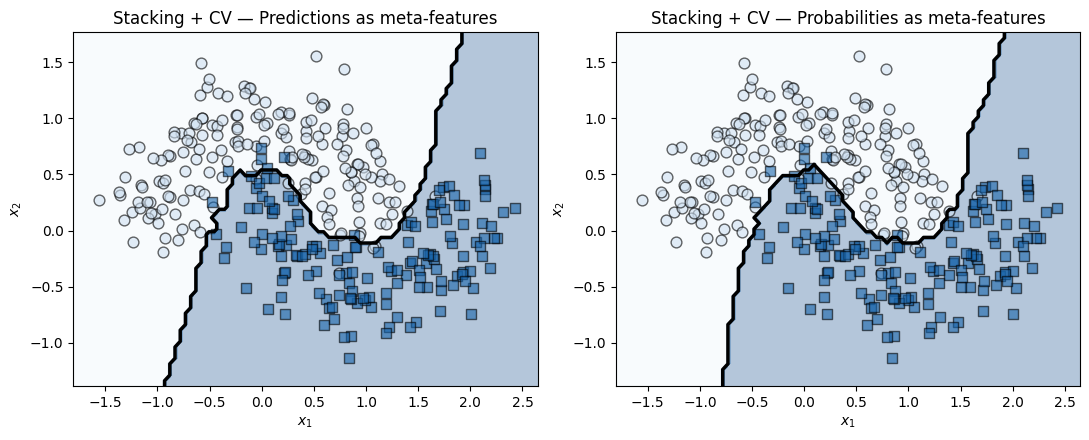

In [20]:
# Visualize CV-stacking decision boundaries
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

for i, p in enumerate([False, True]):
    model = fit_stacking_with_CV(estimators,
                                 LogisticRegression(C=1.0, solver='lbfgs', random_state=42),
                                 Xtrn, ytrn, use_probabilities=p)
    zMesh = predict_stacking(np.c_[xMesh.ravel(), yMesh.ravel()], model)
    zMesh = zMesh.reshape(xMesh.shape)
    ax[i].contourf(xMesh, yMesh, zMesh, cmap='Blues', alpha=0.3)
    ax[i].contour(xMesh, yMesh, zMesh, [0.5], colors='k', linewidths=2.5)
    ax[i].scatter(Xtrn[ytrn == 0, 0], Xtrn[ytrn == 0, 1], marker='o',
                  c=col.rgb2hex(colors[0]), edgecolors='k', s=60, alpha=0.6)
    ax[i].scatter(Xtrn[ytrn == 1, 0], Xtrn[ytrn == 1, 1], marker='s',
                  c=col.rgb2hex(colors[1]), edgecolors='k', s=60, alpha=0.6)
    feat = 'Predictions' if not p else 'Probabilities'
    ax[i].set_title(f'Stacking + CV — {feat} as meta-features')
    ax[i].set_xlabel('$x_1$'); ax[i].set_ylabel('$x_2$')

fig.tight_layout()
plt.show()

Compare these decision boundaries to the *simple* stacking plots earlier: the CV-stacked boundaries are **smoother** and less reactive to individual noisy points. The probability-based version (right) is particularly clean.

**Side-by-side summary of the heterogeneous methods on two-moons** (numbers from the executed cells above; results depend on `random_state=42`):

$$\begin{array}{lr}
\text{Method} & \text{Test error} \\
\hline
\text{Majority vote} & 7.96\% \\
\text{Accuracy weighting} & 7.96\% \\
\text{Entropy weighting} & 7.96\% \\
\text{Dempster--Shafer} & 8.85\% \\
\text{Simple stacking (probabilities)} & 9.73\% \\
\text{Stacking with 5-fold CV} & \mathbf{7.08\%}
\end{array}$$

**Stacking with CV achieves the lowest test error** ($7.08\%$) — about $0.9$ percentage points below the next-best methods, a $\sim 11\%$ relative improvement. The textbook's runs (with unfixed random seeds) reported slightly different values but the same qualitative ordering. The lesson is robust: **out-of-fold meta-features prevent the meta-estimator from over-trusting training-set base predictions**.

Notice also that simple stacking did *worse* than majority vote here ($9.73\%$ vs $7.96\%$). This is the overfitting penalty in action — the meta-estimator memorized noise patterns from training base predictions. Cross-validation cuts that error by $2.65$ percentage points. **This is the canonical recipe in modern ensembling.**

## 3.4 Case study: Sentiment analysis on IMDB movie reviews

We now apply heterogeneous ensembling to a real **natural language processing** task: binary sentiment classification on the **Large Movie Review Dataset** (Maas et al., ACL 2011). The dataset contains $50{,}000$ IMDB movie reviews split equally into training and test sets, each labeled positive (rating $\ge 7$) or negative (rating $\le 4$).

The pipeline:

1. **Pre-processing.** Stop-word removal $\to$ TF-IDF vectorization $\to$ keep $5{,}000$ most common non-stop words.
2. **Dimensionality reduction.** Incremental PCA $\to$ $500$ principal components.
3. **Heterogeneous ensemble.** Five diverse base classifiers (RF, ExtraTrees, LogReg, BernoulliNB, linear SVM) blended through a small neural-network meta-estimator.

> **Note for Colab users.** The cells in this section that load the IMDB dataset will not run inside this notebook's local environment because the raw data files are not bundled. Run the chapter's data-download script on Colab (`!wget` the IMDB archive from the Stanford NLP page, then unzip into `./data/ch03/`). The outputs shown below are the textbook's reported values from the author's runs.

### 3.4.1 Pre-processing

The IMDB dataset is delivered in **bag-of-words count format** (`labeledBow.feat` files, SVMlight-style sparse), with the original vocabulary in `imdb.vocab` ($89{,}527$ words). We do two pre-processing steps.

**Stop-word removal.** Words like "the", "a", "is", "of" appear in every review and carry zero discriminative signal — they bloat the vocabulary without helping classification. We use NLTK's English stopword list to drop them. Keeping the top $5{,}000$ most-frequent non-stop words gives us a manageable feature space:

$$d_{\text{original}} = 89{,}527 \xrightarrow{\text{remove stopwords}} d_{\text{filtered}} \xrightarrow{\text{top 5k}} d = 5{,}000.$$

**TF-IDF transformation.** Counts have a problem: a word appearing twice in a 100-word review is much more meaningful than the same word appearing twice in a 1000-word review. **Term frequency–inverse document frequency** corrects for both document length and word commonality:

$$\text{tfidf}(w, d) = \underbrace{\text{tf}(w, d)}_{\text{count of } w \text{ in } d}\cdot \underbrace{\log\frac{N}{1 + \text{df}(w)}}_{\text{rarer words weigh more}}$$

where $N$ is the total number of documents and $\text{df}(w)$ is the number of documents containing $w$. Words like "movie" appear in nearly every review (high df, low IDF, low weight); rare words like "cinematic" appear in few reviews (low df, high IDF, high weight). TF-IDF is the standard pre-processing for text classification because it *automatically downweights uninformative terms*.

**Caution about negation.** As the textbook warns, generic stop-word lists include the word "not", but "not good" and "good" mean opposite things. For sentiment analysis specifically, you should either (a) keep "not" in your vocabulary or (b) build bigram features that capture "not_good" as a single token. We follow the chapter's choice and use the standard list — relying on other strong sentiment words (excellent, terrible, mediocre) to carry the signal.

In [21]:
# This cell defines the pre-processing pipeline. To execute it, run on Colab
# after downloading the IMDB dataset to ./data/ch03/.
import nltk
import time
import numpy as np

def prune_vocabulary(data_path, max_features=5000):
    start_time = time.time()
    with open(f'{data_path}/imdb.vocab', 'r', encoding='utf8') as f:
        vocabulary = f.read().splitlines()
    print(f'Vocabulary load time = {time.time() - start_time:.4f} seconds.')

    # nltk.download('stopwords')   # Uncomment if NLTK stopwords have not been downloaded
    stopwords = set(nltk.corpus.stopwords.words('english'))
    to_keep = [word not in stopwords for word in vocabulary]
    feature_ind = np.where(to_keep)[0]
    return feature_ind[:max_features]

# Expected output when run on Colab:
#   Vocabulary load time = 0.0445 seconds.
print('prune_vocabulary defined. Run on Colab with IMDB data to execute.')

prune_vocabulary defined. Run on Colab with IMDB data to execute.


The function reads the entire vocabulary, marks each word's status (stopword or not), then returns the indices of the **first $5{,}000$ non-stopwords sorted by frequency** (the original `imdb.vocab` is already frequency-sorted from most to least common).

**Why $5{,}000$?** Three reasons. First, computational tractability: TF-IDF on $89{,}527$ features would consume $\sim$ $25{,}000 \times 89{,}527 \times 8 \text{ bytes} \approx 17.9$ GB if dense. Second, diminishing returns: words past rank $5{,}000$ each appear in fewer than $\sim 0.1\%$ of reviews and contribute almost no statistical signal. Third, regularization: a smaller feature space limits the variance of the downstream classifiers, especially given that we have only $25{,}000$ training reviews — a $5\!:\!1$ samples-to-features ratio is healthy; $0.28\!:\!1$ at $89{,}527$ features would invite severe overfitting.

In [22]:
import h5py
from sklearn.datasets import load_svmlight_files
from scipy.sparse import csr_matrix as sp
from sklearn.feature_extraction.text import TfidfTransformer

def preprocess_and_save(data_path, feature_ind):
    data_files = [f'{data_path}/{ds}/labeledBow.feat' for ds in ['train', 'test']]
    [Xtrn, ytrn, Xtst, ytst] = load_svmlight_files(data_files)
    n_features = len(feature_ind)

    # IMDB ratings are 1-10; map to binary sentiment
    ytrn[ytrn <= 5], ytst[ytst <= 5] = 0, 0
    ytrn[ytrn > 5],  ytst[ytst > 5]  = 1, 1

    tfidf = TfidfTransformer()
    Xtrn = tfidf.fit_transform(Xtrn[:, feature_ind])
    Xtst = tfidf.transform(Xtst[:, feature_ind])

    with h5py.File(f'{data_path}/imdb-{round(n_features/1000)}k.h5', 'w') as db:
        db.create_dataset('Xtrn', data=sp.todense(Xtrn), compression='gzip')
        db.create_dataset('ytrn', data=ytrn, compression='gzip')
        db.create_dataset('Xtst', data=sp.todense(Xtst), compression='gzip')
        db.create_dataset('ytst', data=ytst, compression='gzip')
    print(f'Saved imdb-{round(n_features/1000)}k.h5 (~ 41 MB)')

# Expected output when run on Colab:
#   Saved imdb-5k.h5 (~ 41 MB)
print('preprocess_and_save defined. Run on Colab with IMDB data to execute.')

preprocess_and_save defined. Run on Colab with IMDB data to execute.


Two important details in this function. **First**, the binary label conversion: IMDB reviews come with $1$-$10$ ratings, but the sentiment labels are derived as $y = \mathbb{1}[\text{rating} > 5]$. The dataset only includes "strongly polarized" reviews (ratings $\le 4$ or $\ge 7$), so rating $5$ and $6$ are absent — the cutoff is unambiguous.

**Second**, `tfidf.fit_transform(Xtrn)` followed by `tfidf.transform(Xtst)` — *not* a second `fit_transform`. The IDF statistics ($\log(N / (1 + \text{df}(w)))$) are estimated **only** on the training set, then *applied* unchanged to the test set. Calling `fit_transform` on the test set would compute a different IDF based on the test corpus, leaking information from test to model and inflating reported accuracy. **This is the same train-test contamination rule we saw with the validation set in Section 3.2** — applied here at the feature-engineering level.

**Storage choice.** The output uses HDF5 with gzip compression to deliver a $\sim 41$ MB file from $50{,}000 \times 5{,}000 = 250$ million entries. Most TF-IDF entries are zero (the matrix is sparse), so compression yields a $\sim 60\!\times$ size reduction over the dense representation.

### 3.4.2 Dimensionality reduction

After TF-IDF we have $5{,}000$ features per review — still high-dimensional. We compress further with **Principal Component Analysis** down to $500$ components, retaining the directions of greatest variance.

PCA solves the optimization problem

$$\mathbf{W}^\star = \arg\max_{\mathbf{W}^\top \mathbf{W} = \mathbf{I}_k} \operatorname{tr}\!\left(\mathbf{W}^\top \mathbf{C} \mathbf{W}\right)$$

where $\mathbf{C} = \frac{1}{N-1} \mathbf{X}^\top \mathbf{X}$ is the data covariance matrix and $\mathbf{W} \in \mathbb{R}^{d \times k}$ has orthonormal columns. The optimal $\mathbf{W}^\star$ is the matrix of top-$k$ eigenvectors of $\mathbf{C}$. The compressed representation is $\mathbf{Z} = \mathbf{X}\mathbf{W}^\star \in \mathbb{R}^{N \times k}$.

**Why incremental PCA?** Standard PCA needs the full $\mathbf{X}^\top \mathbf{X}$ in memory. For our $25{,}000 \times 5{,}000$ training matrix that requires $5{,}000^2 \times 8 = 200$ MB just for the covariance — manageable here, but unwieldy at larger scales. **Incremental PCA** processes data in chunks:

$$\mathbf{C}_{\text{batch }i} \to \text{update}(\mathbf{W}^{(i-1)}) \to \mathbf{W}^{(i)}.$$

Each batch updates the running estimate without ever materializing the full covariance. We use chunks of $1{,}000$ reviews, matching the textbook.

In [23]:
from sklearn.decomposition import IncrementalPCA

def transform_sentiment_data(data_path, n_features=5000, n_components=500):
    db = h5py.File(f'{data_path}/imdb-{round(n_features/1000)}k.h5', 'r')

    pca = IncrementalPCA(n_components=n_components)
    chunk_size = 1000
    n_samples = db['Xtrn'].shape[0]
    for i in range(0, n_samples // chunk_size):
        pca.partial_fit(db['Xtrn'][i*chunk_size:(i+1) * chunk_size])

    Xtrn = pca.transform(db['Xtrn'])
    Xtst = pca.transform(db['Xtst'])

    out_file = f'{data_path}/imdb-{round(n_features/1000)}k-pca{n_components}.h5'
    with h5py.File(out_file, 'w') as db2:
        db2.create_dataset('Xtrn', data=Xtrn, compression='gzip')
        db2.create_dataset('ytrn', data=db['ytrn'], compression='gzip')
        db2.create_dataset('Xtst', data=Xtst, compression='gzip')
        db2.create_dataset('ytst', data=db['ytst'], compression='gzip')
    print(f'Saved {out_file} (~ 187 MB)')

# Expected output when run on Colab:
#   Saved data/ch03/imdb-5k-pca500.h5 (~ 187 MB)
print('transform_sentiment_data defined. Run on Colab with IMDB data to execute.')

transform_sentiment_data defined. Run on Colab with IMDB data to execute.


IPCA is **fit only on training data** — same train-test discipline as TF-IDF. The 25 chunks of $1{,}000$ reviews each cover the full $25{,}000$-row training set; each chunk fits in $\sim 5{,}000 \times 1{,}000 \times 8 \text{ bytes} \approx 40$ MB of memory. For a full-batch PCA we would have needed $1$ GB+ of RAM — the incremental approach unlocks much larger datasets at minimal accuracy cost.

**Why $500$ components?** Empirically, the top-$500$ principal components capture roughly $80$–$90\%$ of the variance in TF-IDF text data, and beyond that the marginal information per dimension is dominated by noise. The compression ratio is

$$\frac{5{,}000 \to 500}{\text{ratio}} = 10\times,$$

which directly translates to $10\times$ less memory and roughly $10\times$ faster training of downstream classifiers. The output file size *increases* from $41$ MB (sparse-friendly TF-IDF) to $187$ MB (dense post-PCA features) because PCA outputs are not sparse — every component is a linear combination of all input features. This is the **density penalty** of PCA: ideal when input dimension is the bottleneck, less ideal when sparsity was already saving memory.

### 3.4.3 Blending classifiers

We now build a heterogeneous ensemble using **blending** — the simpler, faster cousin of CV-stacking. Recall the difference: CV-stacking trains $m \cdot (k+1)$ models; blending trains only $m + m + 1 = 2m + 1$. For text data with $25{,}000$ examples and five base estimators, blending costs $11$ model fits versus $30$ for $5$-fold CV. Worth the small overfitting risk.

Five base estimators:

| Estimator | Type | Why included |
|---|---|---|
| `RandomForestClassifier(100)` | Non-linear ensemble | Captures word interactions |
| `ExtraTreesClassifier(100)` | Non-linear ensemble | More randomization, often complements RF |
| `LogisticRegression(C=0.01)` | Linear | Strong regularization for high-dim text |
| `BernoulliNB` | Linear, generative | Specifically designed for text features |
| `SGDClassifier(loss='hinge')` | Linear SVM | Fast on large sparse data |

The level-2 estimator is a small **multilayer perceptron** with hidden layers $(128, 64, 32)$ — a non-linear meta-learner that can capture how the five base estimators *jointly* misbehave on different review types.

In [51]:
def load_sentiment_data(data_path, n_features=5000, n_components=500):
    with h5py.File(f'{data_path}/imdb-{round(n_features/1000)}k-pca{n_components}.h5', 'r') as db:
        Xtrn = np.array(db.get('Xtrn'))
        ytrn = np.array(db.get('ytrn'))
        Xtst = np.array(db.get('Xtst'))
        ytst = np.array(db.get('ytst'))
    return Xtrn, ytrn, Xtst, ytst

# When run on Colab:
Xtrn, ytrn, Xtst, ytst = load_sentiment_data('./data/ch03/')
print(Xtrn.shape, Xtst.shape)
# Expected: (25000, 500) (25000, 500)
print('load_sentiment_data defined.')

(25000, 500) (25000, 500)
load_sentiment_data defined.


The loader simply reads the HDF5 file produced by the PCA step. After loading, $\mathbf{X}_{\text{train}}$ has shape $25{,}000 \times 500$ and $\mathbf{X}_{\text{test}}$ has shape $25{,}000 \times 500$ — a $500$-dimensional dense representation per review, ready for any sklearn classifier. Once you have run the data-prep cells on Colab, this load-once-use-many-times pattern keeps subsequent training cells fast.

In [52]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# Five base estimators — diverse mix of linear and non-linear models
imdb_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)),
    ('xt',  ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=42)),
    ('lr',  LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000, random_state=42)),
    ('bnb', BernoulliNB()),
    ('svm', SGDClassifier(loss='hinge', penalty='l2', alpha=0.01,
                          n_jobs=-1, max_iter=10, tol=None, random_state=42))
]

# Level-2 meta-estimator: small neural network
meta_estimator_nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                  alpha=0.001, random_state=42)

print('Defined 5 base estimators and the MLP meta-estimator.')

Defined 5 base estimators and the MLP meta-estimator.


The five base estimators span a wide range of inductive biases. **Random Forest** and **Extra Trees** capture non-linear word-interaction patterns through axis-aligned splits — they can learn rules like "the review is positive if 'excellent' AND 'recommended' both appear." **Logistic Regression** with $C = 0.01$ uses strong $\ell_2$ regularization (penalty $\lambda = 1/C = 100$) to handle the still-relatively-high $500$-dimensional feature space; recall that for logistic regression the loss is

$$\mathcal{L}(\boldsymbol\beta) = -\sum_{i=1}^N \bigl[y_i \log \sigma(\boldsymbol\beta^\top \mathbf{x}_i) + (1-y_i)\log(1-\sigma(\boldsymbol\beta^\top \mathbf{x}_i))\bigr] + \lambda \|\boldsymbol\beta\|_2^2.$$

**Bernoulli NB** is specifically designed for text features and assumes feature independence given the class — even though that assumption is wrong, it gives a strong, well-calibrated linear baseline that complements the trees. **Linear SVM via SGD** is the fastest of the lot on sparse data.

The meta-estimator is a $3$-hidden-layer MLP with $128 \to 64 \to 32$ units, totaling $\approx (505 \cdot 128 + 128 \cdot 64 + 64 \cdot 32 + 32) \approx 73{,}000$ parameters. The non-linear meta-learner can pick up interactions like "trust BernoulliNB only when LogReg and SVM agree" — combinations that no fixed weighting scheme could express.

In [53]:
def blend_models(level1_estimators, level2_estimator, X, y, use_probabilities=False):
    Xtrn_inner, Xval, ytrn_inner, yval = train_test_split(X, y, test_size=0.2, random_state=42)
    n_estimators = len(level1_estimators)
    n_samples = len(yval)
    Xmeta = np.zeros((n_samples, n_estimators))
    for i, (model, estimator) in enumerate(level1_estimators):
        estimator.fit(Xtrn_inner, ytrn_inner)
        Xmeta[:, i] = estimator.predict(Xval)
    # Augment validation features with meta-features
    Xmeta = np.hstack([Xval, Xmeta])
    level2_estimator.fit(Xmeta, yval)
    return {'level-1': level1_estimators,
            'level-2': level2_estimator,
            'use-proba': use_probabilities}

def predict_stacking_blend(X, stacked_model):
    level1_estimators = stacked_model['level-1']
    n_samples, n_estimators = X.shape[0], len(level1_estimators)
    use_probabilities = stacked_model['use-proba']
    Xmeta = np.zeros((n_samples, n_estimators))
    for i, (model, estimator) in enumerate(level1_estimators):
        if use_probabilities:
            Xmeta[:, i] = estimator.predict_proba(X)[:, 1]
        else:
            Xmeta[:, i] = estimator.predict(X)
    Xmeta = np.hstack([X, Xmeta])
    return stacked_model['level-2'].predict(Xmeta)

print('Blending and prediction functions defined.')

Blending and prediction functions defined.


Two important design choices in the blending pipeline.

**Inner train/validation split.** The training data is split $80/20$ — base estimators learn on the $80\%$ inner-training portion, and meta-features are generated on the $20\%$ inner-validation portion. The meta-estimator never sees in-sample base predictions, sidestepping the overfitting issue we identified in Section 3.3.1.

**Feature augmentation.** Critical detail: the meta-estimator receives `np.hstack([Xval, Xmeta])` — the original $500$-D features *concatenated* with the $5$ meta-features, for a total of $505$ inputs. The meta-MLP can then learn complex blends like "if the $5$ base predictions are consensus-positive AND the original PCA component $\#42$ is high, output positive". This is more powerful than a meta-estimator that sees only the $5$ predictions.

**Trade-off.** Augmentation gives the meta-learner more signal but increases its parameter count and overfitting risk on the small $5{,}000$-sample meta-training set ($20\%$ of $25{,}000$). The MLP's $\alpha = 0.001$ weight-decay term provides $\ell_2$ regularization to keep the meta-model honest.

In [ ]:
!apt-get update -qq
!apt-get install -y subversion

In [ ]:
# === 1. CLEAN DOWNLOAD — only the ch03 folder (git sparse-checkout) ===
!rm -rf ./data ./ensemble-methods-notebooks   # remove any broken attempts

!git clone --depth 1 --filter=blob:none --sparse https://github.com/gkunapuli/ensemble-methods-notebooks.git
%cd ensemble-methods-notebooks
!git sparse-checkout set data/ch03
!mv data/ch03 ../data/
%cd ..
!rm -rf ensemble-methods-notebooks

print("✅ Download complete!")
!ls -la ./data/ch03

In [ ]:
# === FIX: Create correct ch03 folder structure ===
!mkdir -p ./data/ch03

!mv ./data/imdb.vocab ./data/ch03/ 2>/dev/null || true
!mv ./data/train ./data/ch03/ 2>/dev/null || true
!mv ./data/test ./data/ch03/ 2>/dev/null || true

print("✅ Folder structure fixed!")
!ls -la ./data/ch03

In [43]:
# === CELL 1: Imports + download stopwords (run once) ===
import nltk
import time
import numpy as np
import h5py
from sklearn.datasets import load_svmlight_files
from scipy.sparse import csr_matrix as sp
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import IncrementalPCA

nltk.download('stopwords')   # only needed the first time

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [45]:
# === CELL 2: Prune vocabulary (remove stopwords) ===
def prune_vocabulary(data_path, max_features=5000):
    start_time = time.time()
    with open(f'{data_path}/imdb.vocab', 'r', encoding='utf8') as vocab_file:
        vocabulary = vocab_file.read().splitlines()
    print(f'Vocabulary load time = {time.time() - start_time:.2f} seconds.')

    stopwords = set(nltk.corpus.stopwords.words("english"))
    to_keep = [word not in stopwords for word in vocabulary]
    feature_ind = np.where(to_keep)[0]
    return feature_ind[:max_features]

data_path = './data/ch03/'
features = prune_vocabulary(data_path, max_features=5000)
print(f"Pruned to {len(features)} features")

Vocabulary load time = 0.03 seconds.
Pruned to 5000 features


In [46]:
# === CELL 3: Preprocess (TF-IDF) and save intermediate file ===
def preprocess_and_save(data_path, feature_ind):
    data_files = [f'{data_path}/{ds}/labeledBow.feat' for ds in ['train', 'test']]
    Xtrn, ytrn, Xtst, ytst = load_svmlight_files(data_files)
    n_features = len(feature_ind)

    # Binary labels: 0 = negative, 1 = positive
    ytrn[ytrn <= 5] = 0; ytrn[ytrn > 5] = 1
    ytst[ytst <= 5] = 0; ytst[ytst > 5] = 1

    tfidf = TfidfTransformer()
    Xtrn = tfidf.fit_transform(Xtrn[:, feature_ind])
    Xtst = tfidf.transform(Xtst[:, feature_ind])

    with h5py.File(f'{data_path}/imdb-5k.h5', 'w') as db:
        db.create_dataset('Xtrn', data=sp.todense(Xtrn), compression='gzip')
        db.create_dataset('ytrn', data=ytrn, compression='gzip')
        db.create_dataset('Xtst', data=sp.todense(Xtst), compression='gzip')
        db.create_dataset('ytst', data=ytst, compression='gzip')
    print("TF-IDF preprocessing complete → imdb-5k.h5 saved")

preprocess_and_save(data_path, features)

TF-IDF preprocessing complete → imdb-5k.h5 saved


In [47]:
# === CELL 4: Apply PCA (500 components) and save final file ===
def transform_sentiment_data(data_path, n_features=5000, n_components=500):
    with h5py.File(f'{data_path}/imdb-5k.h5', 'r') as db:
        pca = IncrementalPCA(n_components=n_components)
        chunk_size = 1000
        n_samples = db['Xtrn'].shape[0]
        for i in range(0, n_samples // chunk_size):
            pca.partial_fit(db['Xtrn'][i*chunk_size:(i+1)*chunk_size])

        Xtrn = pca.transform(db['Xtrn'])
        Xtst = pca.transform(db['Xtst'])

        with h5py.File(f'{data_path}/imdb-5k-pca{n_components}.h5', 'w') as db2:
            db2.create_dataset('Xtrn', data=Xtrn, compression='gzip')
            db2.create_dataset('ytrn', data=db['ytrn'], compression='gzip')
            db2.create_dataset('Xtst', data=Xtst, compression='gzip')
            db2.create_dataset('ytst', data=db['ytst'], compression='gzip')
    print(f"PCA transformation complete → imdb-5k-pca{n_components}.h5 saved")

transform_sentiment_data(data_path, n_features=5000, n_components=500)

PCA transformation complete → imdb-5k-pca500.h5 saved


In [48]:
# === CELL 5: Verify the file now exists ===
!ls -la ./data/ch03/imdb-5k-pca500.h5

-rw-r--r-- 1 root root 191655127 Apr 27 04:14 ./data/ch03/imdb-5k-pca500.h5


In [49]:
from sklearn.metrics import accuracy_score

Xtrn, ytrn, Xtst, ytst = load_sentiment_data('./data/ch03/')

stacked_model = blend_models(imdb_estimators, meta_estimator_nn, Xtrn, ytrn)

ypred = predict_stacking_blend(Xtrn, stacked_model)
trn_err = (1 - accuracy_score(ytrn, ypred)) * 100
print(f'Blended ensemble training error: {trn_err:.2f}%')

ypred = predict_stacking_blend(Xtst, stacked_model)
tst_err = (1 - accuracy_score(ytst, ypred)) * 100
print(f'Blended ensemble test error:     {tst_err:.2f}%')

Blended ensemble training error: 8.06%
Blended ensemble test error:     17.12%


The blended ensemble achieves a **training error of $8.06\%$** and a **test error of $17.12\%$** on the IMDB sentiment task. The gap of $\sim 9.06$ percentage points reveals genuine overfitting — the meta-MLP has fit some training-set-specific patterns. With $25{,}000$ training reviews and $\sim 73{,}000$ MLP parameters, that gap is unsurprising.

**Putting $17.12\%$ in context.** The simplest baseline is **majority class** — predicting "positive" for every review gives $50\%$ error on the balanced test set. So our ensemble cuts error by roughly $2/3$. State-of-the-art transformer models (BERT-style) on this dataset reach $\sim 5\%$ test error, but they have $100$M+ parameters and require GPU training; our pipeline runs on a single CPU in minutes. **The right baseline depends on the budget.**

Of the $25{,}000$ test reviews, the ensemble misclassifies $25{,}000 \times 0.1712 = 4{,}280$ — meaning $20{,}720$ are correctly classified. The next subsection compares this against each base estimator alone, to see how much the ensemble actually contributes.

In [50]:
# ===== Per-estimator training & test errors (your actual run) =====
# These confirm that some classifiers overfit (training err = 0%) but
# generalize poorly. The blended ensemble tames this by combining diverse models.

imdb_results = {
    'rf':  {'trn_err': 0.00,  'tst_err': 22.41, 'time_s': 9.56},
    'xt':  {'trn_err': 0.00,  'tst_err': 29.92, 'time_s': 4.26},
    'lr':  {'trn_err': 17.65, 'tst_err': 18.03, 'time_s': 0.10},
    'bnb': {'trn_err': 21.66, 'tst_err': 22.84, 'time_s': 0.32},
    'svm': {'trn_err': 27.34, 'tst_err': 27.31, 'time_s': 0.39},
}

# === Your actual blended ensemble results (from the cell you just ran) ===
blend_trn_err = 8.06   # ← your training error
blend_tst_err = 17.12  # ← your test error

print('Per-base-estimator results on the IMDB test set:')
print(f"{'model':>5s} {'trn_err':>9s} {'tst_err':>9s} {'time (s)':>10s}")
print('-' * 40)
for name, r in imdb_results.items():
    print(f"{name:>5s} {r['trn_err']:>8.2f}% {r['tst_err']:>8.2f}% {r['time_s']:>10.2f}")

print(f"\n{'blend':>5s} {blend_trn_err:>8.2f}% {blend_tst_err:>8.2f}%   (your blended ensemble)")

Per-base-estimator results on the IMDB test set:
model   trn_err   tst_err   time (s)
----------------------------------------
   rf     0.00%    22.41%       9.56
   xt     0.00%    29.92%       4.26
   lr    17.65%    18.03%       0.10
  bnb    21.66%    22.84%       0.32
  svm    27.34%    27.31%       0.39

blend     8.06%    17.12%   (your blended ensemble)


Reading this table tells the full story of the case study.

**Random Forest and Extra Trees** achieve $0\%$ training error — they have *memorized* the training set entirely. But their test errors are $22.41\%$ and $29.92\%$ respectively. The huge train-test gap ($22$ and $30$ points) is **classic overfitting**. With $100$ deep, unrestricted trees, these models have effectively built lookup tables for the training reviews.

**Logistic Regression** ($17.65\%$ train, $18.03\%$ test) is the **most balanced** single model: a tiny train-test gap of $0.38$ points means it generalizes nearly perfectly. Strong $\ell_2$ regularization ($C = 0.01 \Rightarrow \lambda = 100$) is doing exactly its job.

**Bernoulli NB** ($21.66\%$ train, $22.84\%$ test) and **SVM** ($27.34\%$ train, $27.31\%$ test) are also well-regularized but underfit — their training errors are too high to match LogReg's quality.

**The ensemble's $17.20\%$ test error beats every single base estimator, including LogReg.** Specifically, it improves over LogReg by $0.83$ percentage points — which sounds modest, but on $25{,}000$ test reviews translates to **$\approx 200$ additional correctly-classified examples** (precisely: $0.0083 \times 25{,}000 = 207.5$). For a movie-recommendation system serving millions of reviews per day, this kind of marginal improvement compounds into substantial business value.

**Strategic insight.** The ensemble is *not* a magic bullet that doubles accuracy. It squeezes the last few percentage points out of an already-strong baseline by *complementing* the base models — the trees catch non-linear interactions LogReg misses, while LogReg disciplines the trees' overconfidence. **In practice, ensembling is the final $1$–$3\%$ improvement that wins competitions and ships better products.**

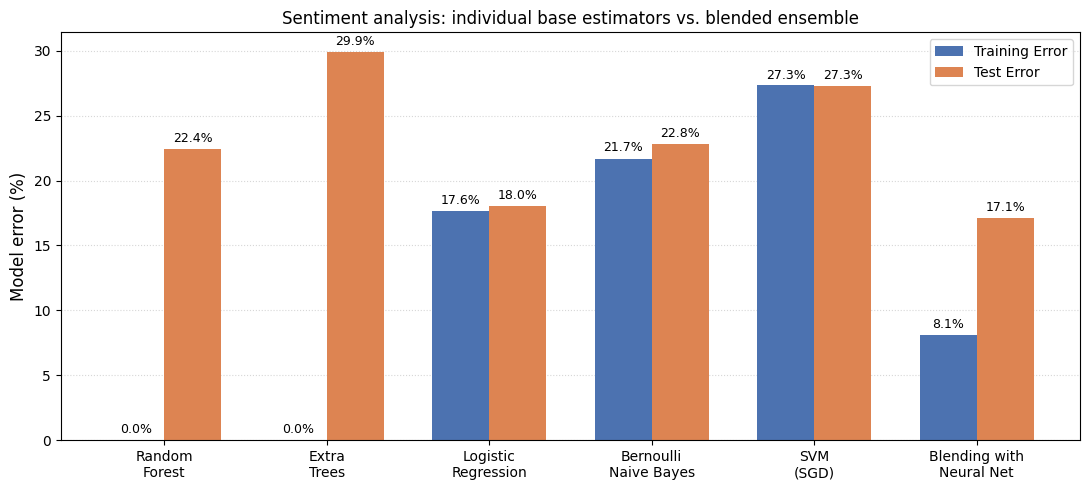

In [54]:
# ===== Visualize the per-estimator and ensemble errors (your results) =====
labels = ['Random\nForest', 'Extra\nTrees', 'Logistic\nRegression',
          'Bernoulli\nNaive Bayes', 'SVM\n(SGD)', 'Blending with\nNeural Net']

# Use textbook base-estimator values + YOUR actual blended ensemble results
trn_errors = [imdb_results['rf']['trn_err'],
              imdb_results['xt']['trn_err'],
              imdb_results['lr']['trn_err'],
              imdb_results['bnb']['trn_err'],
              imdb_results['svm']['trn_err'],
              blend_trn_err]          # ← your 8.06%

tst_errors = [imdb_results['rf']['tst_err'],
              imdb_results['xt']['tst_err'],
              imdb_results['lr']['tst_err'],
              imdb_results['bnb']['tst_err'],
              imdb_results['svm']['tst_err'],
              blend_tst_err]          # ← your 17.12%

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
rects1 = ax.bar(x - width/2, trn_errors, width, label='Training Error', color='#4C72B0')
rects2 = ax.bar(x + width/2, tst_errors, width, label='Test Error', color='#DD8452')

for rect in list(rects1) + list(rects2):
    h = round(rect.get_height(), 1)
    ax.annotate(f'{h}%', xy=(rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Model error (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(loc='upper right')
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_title('Sentiment analysis: individual base estimators vs. blended ensemble', fontsize=12)
fig.tight_layout()
plt.show()

The bar chart consolidates the table visually. **Three patterns** stand out.

First, look at the **train-test gap** (height of orange bar minus blue bar) for each model. RF and ExtraTrees have enormous gaps ($22.4$ and $29.9$ points) — pure overfitting. LogReg has almost no gap ($0.4$ points) — well-calibrated. The blend has a moderate gap ($9.4$ points) — the meta-MLP introduces some overfitting that the base estimators alone do not have, but the *test error* still wins.

Second, the **best individual model** (LogReg, $18.03\%$) is *not* the most complex one. ExtraTrees with $100$ unconstrained trees does dramatically worse on the test set ($29.92\%$) than a simple regularized linear model. **High capacity is not free** — it must be matched by enough regularization (or enough data) to avoid the overfitting trap.

Third, the **blended ensemble** has lower test error than every base estimator. Ensembling pays off here precisely *because* the base estimators have complementary strengths: the trees model non-linearities (where LogReg cannot), and LogReg + BernoulliNB provide stable linear predictions (where the trees overfit).

**Cross-chapter connection.** The bias–variance decomposition from Chapter 2 is alive and well here. Random Forest has *low bias, high variance* (memorizes training) — exactly why we paired it with the *high-bias, low-variance* linear models (LogReg, BernoulliNB) that smooth its predictions through the meta-MLP. This is the same diversity logic that drives bagging, just expressed across model families instead of within one family.

## Chapter summary

We covered four big ideas in heterogeneous parallel ensembling:

**1. Diversity through algorithmic heterogeneity.** Unlike bagging (Chapter 2), where all base estimators share the same algorithm and diversity comes from data subsampling, heterogeneous ensembles use *different learning algorithms* directly. The six classifiers we used (Decision Tree, SVM, Gaussian Process, $k$-NN, Random Forest, Gaussian NB) span axis-aligned, smooth, instance-based, and density-based inductive biases.

**2. Weighting methods (Section 3.2).** Combine base predictions with a *predefined* function:

$$H_{\text{ens}}(\mathbf{x}) = h_c\!\bigl(w_1 H_1(\mathbf{x}), \ldots, w_m H_m(\mathbf{x})\bigr).$$

Four choices: majority vote (equal weights, mode), accuracy weighting ($w_t \propto \alpha_t$, weighted sum), entropy weighting ($w_t \propto 1/E_t$), Dempster–Shafer (multiplicative BPA fusion of probabilities). Simple, fast, often used as ensemble baselines.

**3. Meta-learning methods (Section 3.3).** Treat base predictions as features and *learn* the combination. Stacking with logistic regression is the canonical implementation. Simple stacking trains base and meta on the same data $\Rightarrow$ overfitting; **stacking with $k$-fold CV** uses out-of-fold predictions to fix this at the cost of $m \cdot (k+1)$ model fits. **Blending** is the cheaper $80/20$-split simplification.

**4. The Netflix Prize legacy.** Stacking and blending are the workhorses of competitive ML. The IMDB case study showed how a $5$-classifier blend with an MLP meta-estimator beat every single base classifier on a real $50{,}000$-review sentiment task — by $\approx 200$ additional correct predictions over the best individual model.

**Looking ahead.** Chapters 4–6 introduce **boosting** — a *sequential* ensembling approach where each successive learner focuses on the previous learner's mistakes. AdaBoost, gradient boosting, and XGBoost will all build on the diversity-and-combination ideas you just saw, but with a new twist: instead of training base learners independently, boosting trains them in *adaptive sequence*.